# Notebook 02 - Exploratory Data Analysis (EDA)
## Cardiovascular Care Deserts in Para, Brazil (2019-2023)

**What this notebook does:**
Explores the cleaned dataset visually and statistically to understand distributions,
identify patterns, and document the key findings that will drive the clustering analysis
and support the manuscript's Results section.

**Why EDA comes before modeling:**
Running K-Means without understanding the data is like drawing a map before exploring
the territory. EDA tells you what the data actually contains, which variables carry
signal, where outliers live, and whether your research hypothesis is even visible in
the numbers before you commit to a model.

**Every figure produced here is a manuscript candidate.**

---

## Section 0 - Imports & Load Clean Data

We load the processed CSV from notebook 01. No cleaning is repeated here.
Each notebook has one job; this one is exploration and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style - consistent across all figures in this project
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})

ACCENT_RED  = '#C0392B'
ACCENT_BLUE = '#2471A3'
ACCENT_GREY = '#808B96'
HIGHLIGHT   = '#F39C12'

df = pd.read_csv('../data/processed/para_cardiovascular_clean.csv',
                 dtype={'cod_ibge': str})

print(f'Dataset loaded: {len(df)} municipalities, {len(df.columns)} columns')
print(f'Study period: 2019-2023 | State: Para, Brazil')
print(df.dtypes.to_string())

Dataset loaded: 144 municipalities, 16 columns
Study period: 2019-2023 | State: Para, Brazil
cod_ibge                   str
nome_municipio             str
mort_2019              float64
mort_2020              float64
mort_2021              float64
mort_2022              float64
mort_2023              float64
mort_total             float64
aih_aprovadas          float64
valor_total_reais      float64
populacao                int64
pib_medio_mil_reais    float64
taxa_mort_100k         float64
taxa_proc_100k         float64
pib_per_capita         float64
crescimento_mort       float64


---
## Section 1 - The Headline Finding

Before any statistics, we establish the central empirical fact of this project.

**Research question:** Do municipalities in Para have equitable access to cardiac catheterization?

**Answer from the raw data:** No. Two municipalities out of 144 performed 100% of all
cardiac catheterization procedures recorded in SUS between 2019 and 2023.

This section makes that fact visually undeniable.

In [2]:
total_proc   = df['aih_aprovadas'].sum()
with_proc    = df[df['aih_aprovadas'] > 0].copy()
without_proc = df[df['aih_aprovadas'] == 0].copy()

print('=== PROCEDURE CONCENTRATION ===')
print(f'Total catheterizations (2019-2023) : {int(total_proc):,}')
print(f'Municipalities WITH procedures     : {len(with_proc)} ({len(with_proc)/len(df)*100:.1f}%)')
print(f'Municipalities WITHOUT procedures  : {len(without_proc)} ({len(without_proc)/len(df)*100:.1f}%)')
print()
print('Breakdown by municipality:')
print(with_proc[['nome_municipio','aih_aprovadas','valor_total_reais']]
      .assign(share_pct=lambda x: (x['aih_aprovadas']/total_proc*100).round(1))
      .to_string(index=False))

=== PROCEDURE CONCENTRATION ===
Total catheterizations (2019-2023) : 5,324
Municipalities WITH procedures     : 2 (1.4%)
Municipalities WITHOUT procedures  : 142 (98.6%)

Breakdown by municipality:
nome_municipio  aih_aprovadas  valor_total_reais  share_pct
    ANANINDEUA           64.0          313573.94        1.2
         BELEM         5260.0        29413499.28       98.8


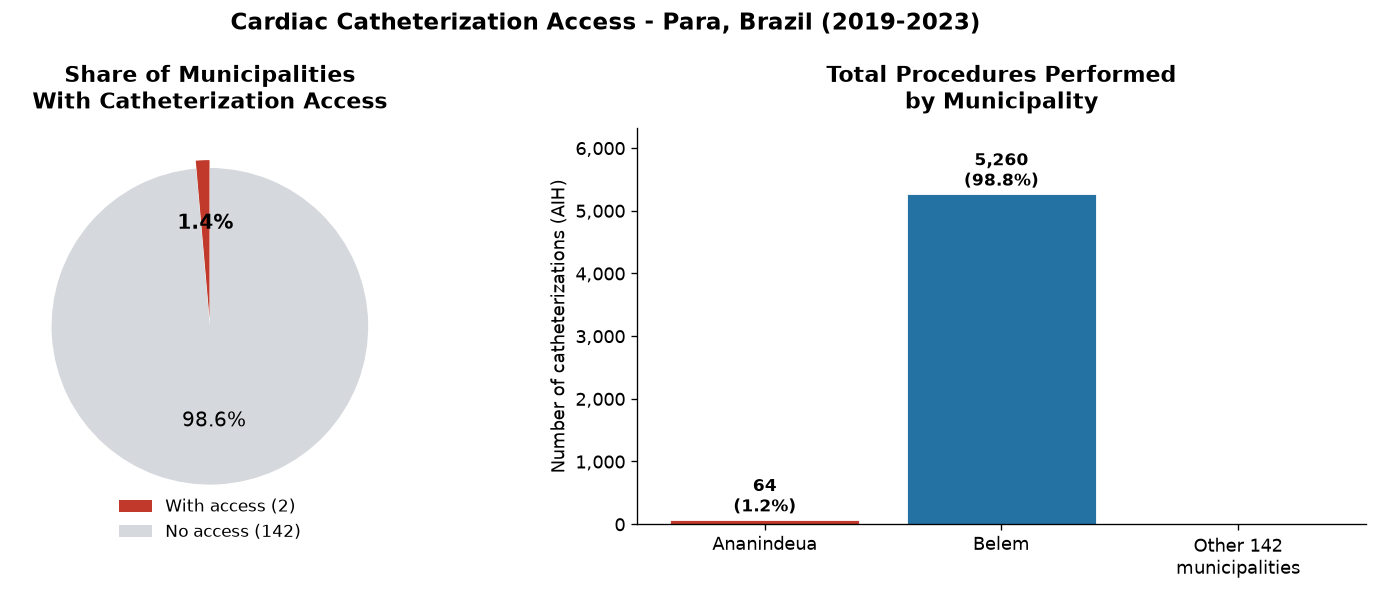

Figure saved: figures/02_procedure_concentration.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cardiac Catheterization Access - Para, Brazil (2019-2023)',
             fontsize=14, fontweight='bold')

# Left: pie chart of municipality count
ax = axes[0]
sizes   = [len(with_proc), len(without_proc)]
colors  = [ACCENT_RED, '#D5D8DC']
explode = [0.05, 0]
wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}, pctdistance=0.6
)
autotexts[0].set_fontweight('bold')
ax.set_title('Share of Municipalities\nWith Catheterization Access', pad=12)
ax.legend(['With access (2)', 'No access (142)'], loc='lower center',
          fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))

# Right: bar chart of total procedures
ax2 = axes[1]
labels = with_proc['nome_municipio'].str.title().tolist() + ['Other 142\nmunicipalities']
values = with_proc['aih_aprovadas'].tolist() + [0]
bar_colors = [ACCENT_RED, ACCENT_BLUE, '#D5D8DC']
bars = ax2.bar(labels, values, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(val):,}\n({val/total_proc*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Total Procedures Performed\nby Municipality', pad=12)
ax2.set_ylabel('Number of catheterizations (AIH)')
ax2.set_ylim(0, max(values) * 1.2)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('figures/02_procedure_concentration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/02_procedure_concentration.png')

---
## Section 2 - Mortality Distribution

**What we are measuring:**
`taxa_mort_100k` = total cardiovascular deaths per 100,000 inhabitants across 2019-2023.
This is the primary outcome variable of the study.

**What to look for:**
- The overall range: are differences between municipalities large or small?
- The shape: is mortality normally distributed or skewed?
- Which municipalities sit at the extremes?

In [4]:
print('=== CARDIOVASCULAR MORTALITY RATE (per 100k inhabitants) ===')
print(df['taxa_mort_100k'].describe().round(2).to_string())
print(f'\nState total CV deaths : {int(df["mort_total"].sum()):,}')
print(f'State population      : {int(df["populacao"].sum()):,}')
print(f'State rate            : {df["mort_total"].sum()/df["populacao"].sum()*100000:.1f} per 100k')

=== CARDIOVASCULAR MORTALITY RATE (per 100k inhabitants) ===
count    144.00
mean     178.64
std       74.78
min       48.72
25%      126.09
50%      166.92
75%      224.47
max      399.68

State total CV deaths : 16,677
State population      : 8,777,124
State rate            : 190.0 per 100k


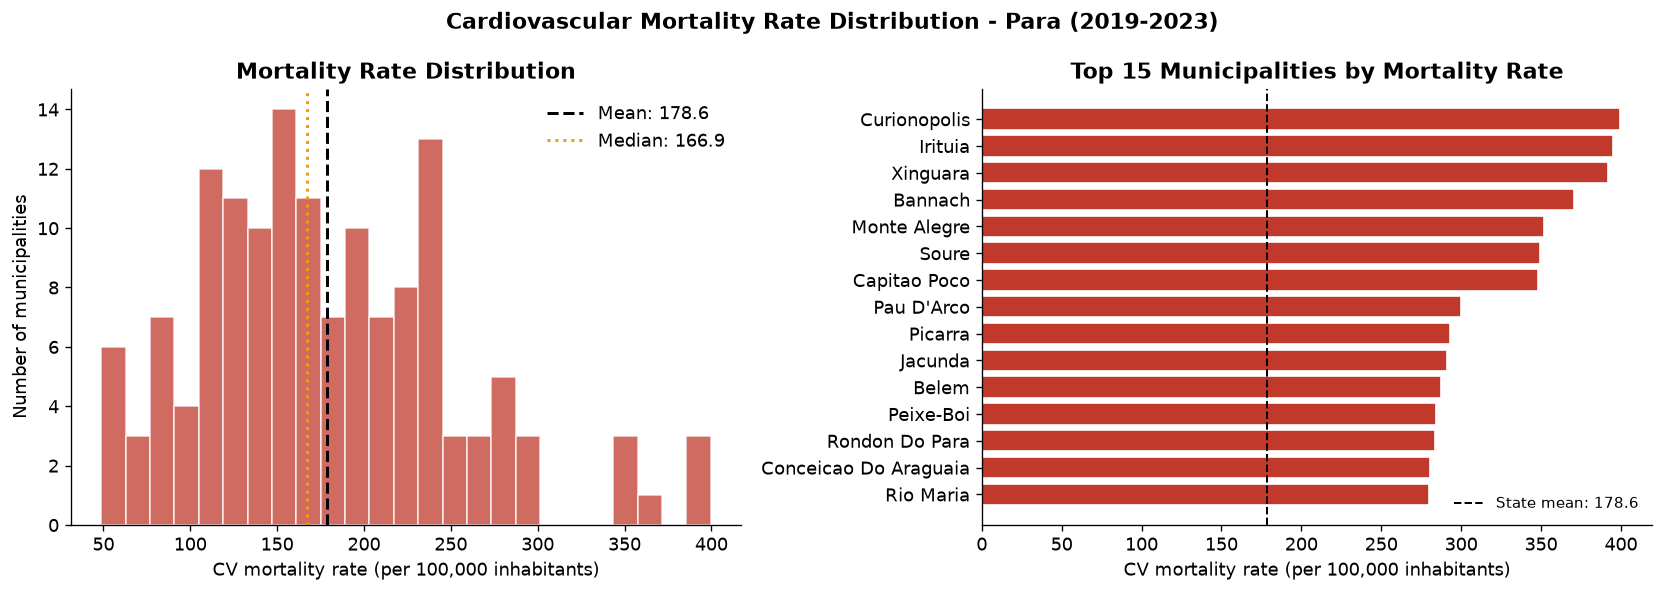

Figure saved: figures/03_mortality_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cardiovascular Mortality Rate Distribution - Para (2019-2023)',
             fontsize=13, fontweight='bold')

# Left: histogram
ax = axes[0]
ax.hist(df['taxa_mort_100k'], bins=25, color=ACCENT_RED,
        alpha=0.75, edgecolor='white')
mean_val   = df['taxa_mort_100k'].mean()
median_val = df['taxa_mort_100k'].median()
ax.axvline(mean_val,   color='black',   linestyle='--', lw=1.8,
           label=f'Mean: {mean_val:.1f}')
ax.axvline(median_val, color=HIGHLIGHT, linestyle=':',  lw=1.8,
           label=f'Median: {median_val:.1f}')
ax.set_xlabel('CV mortality rate (per 100,000 inhabitants)')
ax.set_ylabel('Number of municipalities')
ax.set_title('Mortality Rate Distribution')
ax.legend(frameon=False)

# Right: top 15 municipalities
ax2 = axes[1]
top15 = df.nlargest(15, 'taxa_mort_100k')[['nome_municipio','taxa_mort_100k']].iloc[::-1]
bar_colors2 = [ACCENT_RED if v > mean_val else ACCENT_GREY
               for v in top15['taxa_mort_100k']]
ax2.barh(top15['nome_municipio'].str.title(), top15['taxa_mort_100k'],
         color=bar_colors2, edgecolor='white')
ax2.axvline(mean_val, color='black', linestyle='--', lw=1.2,
            label=f'State mean: {mean_val:.1f}')
ax2.set_xlabel('CV mortality rate (per 100,000 inhabitants)')
ax2.set_title('Top 15 Municipalities by Mortality Rate')
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('figures/03_mortality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/03_mortality_distribution.png')

---
## Section 3 - Temporal Trends (2019-2023)

**Why this matters for the manuscript:**
The study period includes COVID-19 (2020-2022). Pandemic-era disruption of healthcare
access is well-documented globally. We expect a mortality spike in 2020-2021 driven by
delayed or cancelled cardiovascular care.

Documenting this trend contextualizes the clustering results: municipalities with weaker
baseline access likely suffered disproportionately during this period.

In [6]:
year_cols = ['mort_2019','mort_2020','mort_2021','mort_2022','mort_2023']
yearly    = df[year_cols].sum()
years     = [2019, 2020, 2021, 2022, 2023]

print('State-level cardiovascular deaths by year:')
for i, (yr, val) in enumerate(zip(years, yearly)):
    if i == 0:
        print(f'  {yr}: {int(val):,}  (baseline)')
    else:
        prev = yearly.iloc[i-1]
        print(f'  {yr}: {int(val):,}  ({(val-prev)/prev*100:+.1f}% vs prior year)')

print(f'\nOverall change 2019 to 2023: {(yearly.iloc[-1]-yearly.iloc[0])/yearly.iloc[0]*100:+.1f}%')
print(f'Peak year: {years[yearly.values.argmax()]} ({int(yearly.max()):,} deaths)')

State-level cardiovascular deaths by year:
  2019: 3,073  (baseline)
  2020: 3,248  (+5.7% vs prior year)
  2021: 3,410  (+5.0% vs prior year)
  2022: 3,382  (-0.8% vs prior year)
  2023: 3,564  (+5.4% vs prior year)

Overall change 2019 to 2023: +16.0%
Peak year: 2023 (3,564 deaths)


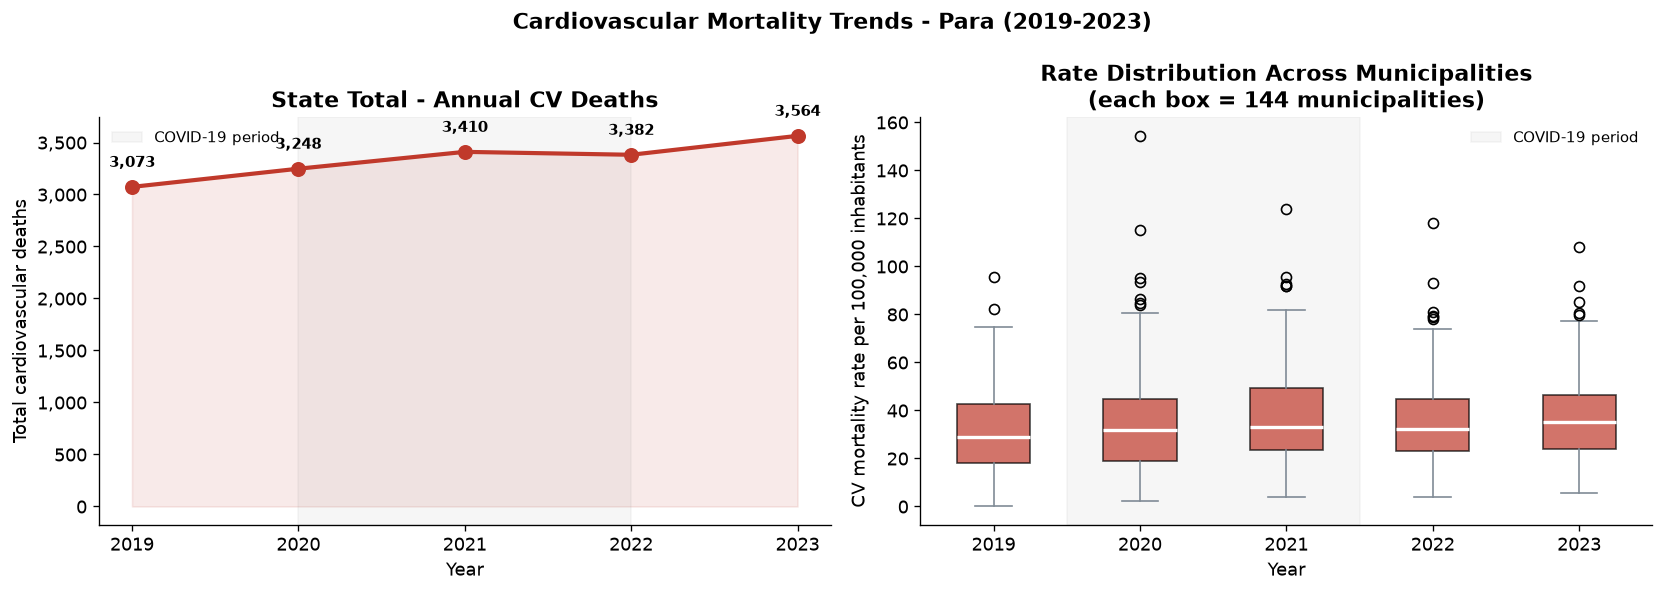

Figure saved: figures/04_temporal_trends.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cardiovascular Mortality Trends - Para (2019-2023)',
             fontsize=13, fontweight='bold')

# Left: state total by year
ax = axes[0]
ax.plot(years, yearly.values, color=ACCENT_RED, linewidth=2.5,
        marker='o', markersize=8, zorder=3)
ax.fill_between(years, yearly.values, alpha=0.1, color=ACCENT_RED)

for yr, val in zip(years, yearly.values):
    ax.annotate(f'{int(val):,}', (yr, val),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, fontweight='bold')

ax.axvspan(2020, 2022, alpha=0.07, color='grey', label='COVID-19 period')
ax.set_xlabel('Year')
ax.set_ylabel('Total cardiovascular deaths')
ax.set_title('State Total - Annual CV Deaths')
ax.set_xticks(years)
ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Right: boxplot of per-municipality rates by year
ax2 = axes[1]
per_yr_rates = [
    (df[col] / df['populacao'] * 100_000).dropna().values
    for col in year_cols
]
bp = ax2.boxplot(per_yr_rates, patch_artist=True, widths=0.5,
                  medianprops=dict(color='white', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(ACCENT_RED)
    patch.set_alpha(0.7)
for element in ['whiskers','caps','fliers']:
    for item in bp[element]:
        item.set_color(ACCENT_GREY)

ax2.set_xticklabels(years)
ax2.set_xlabel('Year')
ax2.set_ylabel('CV mortality rate per 100,000 inhabitants')
ax2.set_title('Rate Distribution Across Municipalities\n(each box = 144 municipalities)')
ax2.axvspan(1.5, 3.5, alpha=0.07, color='grey', label='COVID-19 period')
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('figures/04_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/04_temporal_trends.png')

---
## Section 4 - Economic Gradient

**Hypothesis being tested:**
Wealthier municipalities (higher GDP per capita) have better cardiovascular care access
and potentially lower mortality rates.

If true, we expect a negative correlation between `pib_per_capita` and `taxa_mort_100k`,
and the clustering algorithm will naturally separate municipalities along economic lines
in an interpretable and scientifically meaningful way.

In [8]:
features = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']
corr = df[features].corr().round(3)

print('=== PEARSON CORRELATION MATRIX ===')
print(corr.to_string())
print()
print('Key relationships:')
print(f'  Mortality vs GDP per capita : r = {corr.loc["taxa_mort_100k","pib_per_capita"]:.3f}')
print(f'  Mortality vs Procedures     : r = {corr.loc["taxa_mort_100k","taxa_proc_100k"]:.3f}')
print(f'  GDP vs Procedures           : r = {corr.loc["pib_per_capita","taxa_proc_100k"]:.3f}')

=== PEARSON CORRELATION MATRIX ===
                  taxa_mort_100k  taxa_proc_100k  pib_per_capita  crescimento_mort
taxa_mort_100k             1.000           0.123           0.095            -0.075
taxa_proc_100k             0.123           1.000          -0.003            -0.025
pib_per_capita             0.095          -0.003           1.000            -0.063
crescimento_mort          -0.075          -0.025          -0.063             1.000

Key relationships:
  Mortality vs GDP per capita : r = 0.095
  Mortality vs Procedures     : r = 0.123
  GDP vs Procedures           : r = -0.003


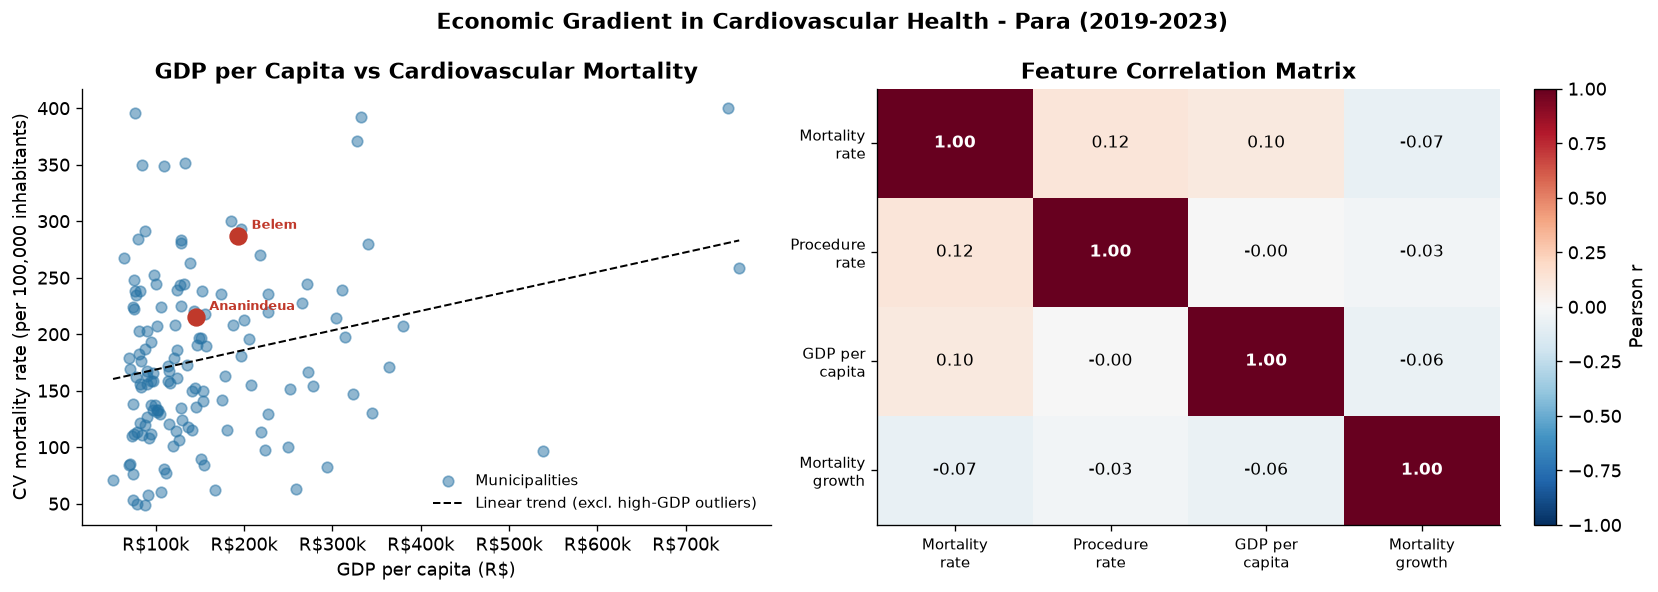

Figure saved: figures/05_economic_gradient.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Economic Gradient in Cardiovascular Health - Para (2019-2023)',
             fontsize=13, fontweight='bold')

# Left: scatter GDP vs mortality
ax = axes[0]
mask_outlier = df['pib_per_capita'] < 1_000_000
ax.scatter(df.loc[mask_outlier, 'pib_per_capita'],
           df.loc[mask_outlier, 'taxa_mort_100k'],
           color=ACCENT_BLUE, alpha=0.5, s=40, label='Municipalities')

for _, row in df[df['aih_aprovadas'] > 0].iterrows():
    ax.scatter(row['pib_per_capita'], row['taxa_mort_100k'],
               color=ACCENT_RED, s=100, zorder=5)
    ax.annotate(row['nome_municipio'].title(),
                (row['pib_per_capita'], row['taxa_mort_100k']),
                textcoords='offset points', xytext=(8, 4), fontsize=8,
                color=ACCENT_RED, fontweight='bold')

d_clean = df[mask_outlier].dropna(subset=['pib_per_capita','taxa_mort_100k'])
z = np.polyfit(d_clean['pib_per_capita'], d_clean['taxa_mort_100k'], 1)
p = np.poly1d(z)
x_line = np.linspace(d_clean['pib_per_capita'].min(), d_clean['pib_per_capita'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.2,
        label='Linear trend (excl. high-GDP outliers)')

ax.set_xlabel('GDP per capita (R$)')
ax.set_ylabel('CV mortality rate (per 100,000 inhabitants)')
ax.set_title('GDP per Capita vs Cardiovascular Mortality')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
ax.legend(frameon=False, fontsize=9)

# Right: correlation heatmap
ax2 = axes[1]
labels = ['Mortality\nrate', 'Procedure\nrate', 'GDP per\ncapita', 'Mortality\ngrowth']
im = ax2.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(4))
ax2.set_yticks(range(4))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_yticklabels(labels, fontsize=9)
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f'{corr.values[i,j]:.2f}',
                 ha='center', va='center', fontsize=10,
                 fontweight='bold' if abs(corr.values[i,j]) > 0.3 else 'normal',
                 color='white' if abs(corr.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax2, fraction=0.046, label='Pearson r')
ax2.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('figures/05_economic_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/05_economic_gradient.png')

---
## Section 5 - Access Gap Visualization

**The access gap in one chart:**
Side-by-side comparison of where people die from cardiovascular disease
vs where cardiac catheterization is actually available.

This is the manuscript's central figure.

In [10]:
top20_mort = df.nlargest(20, 'taxa_mort_100k')[
    ['nome_municipio','taxa_mort_100k','aih_aprovadas']
]

print('Top 20 municipalities by cardiovascular mortality rate:')
print(top20_mort.assign(
    has_procedure=top20_mort['aih_aprovadas'].apply(lambda x: 'YES' if x > 0 else 'NO')
)[['nome_municipio','taxa_mort_100k','has_procedure']].to_string(index=False))

n_with = int((top20_mort['aih_aprovadas'] > 0).sum())
print(f'\nOf the 20 highest-mortality municipalities:')
print(f'  With catheterization access : {n_with}')
print(f'  Without                     : {20 - n_with}')

Top 20 municipalities by cardiovascular mortality rate:
       nome_municipio  taxa_mort_100k has_procedure
         CURIONOPOLIS      399.684756            NO
              IRITUIA      395.232697            NO
             XINGUARA      391.932359            NO
              BANNACH      370.484718            NO
         MONTE ALEGRE      351.695860            NO
                SOURE      349.487418            NO
         CAPITAO POCO      348.336236            NO
           PAU D'ARCO      299.681588            NO
              PICARRA      292.848335            NO
              JACUNDA      290.827371            NO
                BELEM      287.237291           YES
            PEIXE-BOI      284.512618            NO
       RONDON DO PARA      283.610683            NO
CONCEICAO DO ARAGUAIA      280.577782            NO
            RIO MARIA      280.096661            NO
 FLORESTA DO ARAGUAIA      269.983608            NO
           TERRA ALTA      267.312672            NO
        

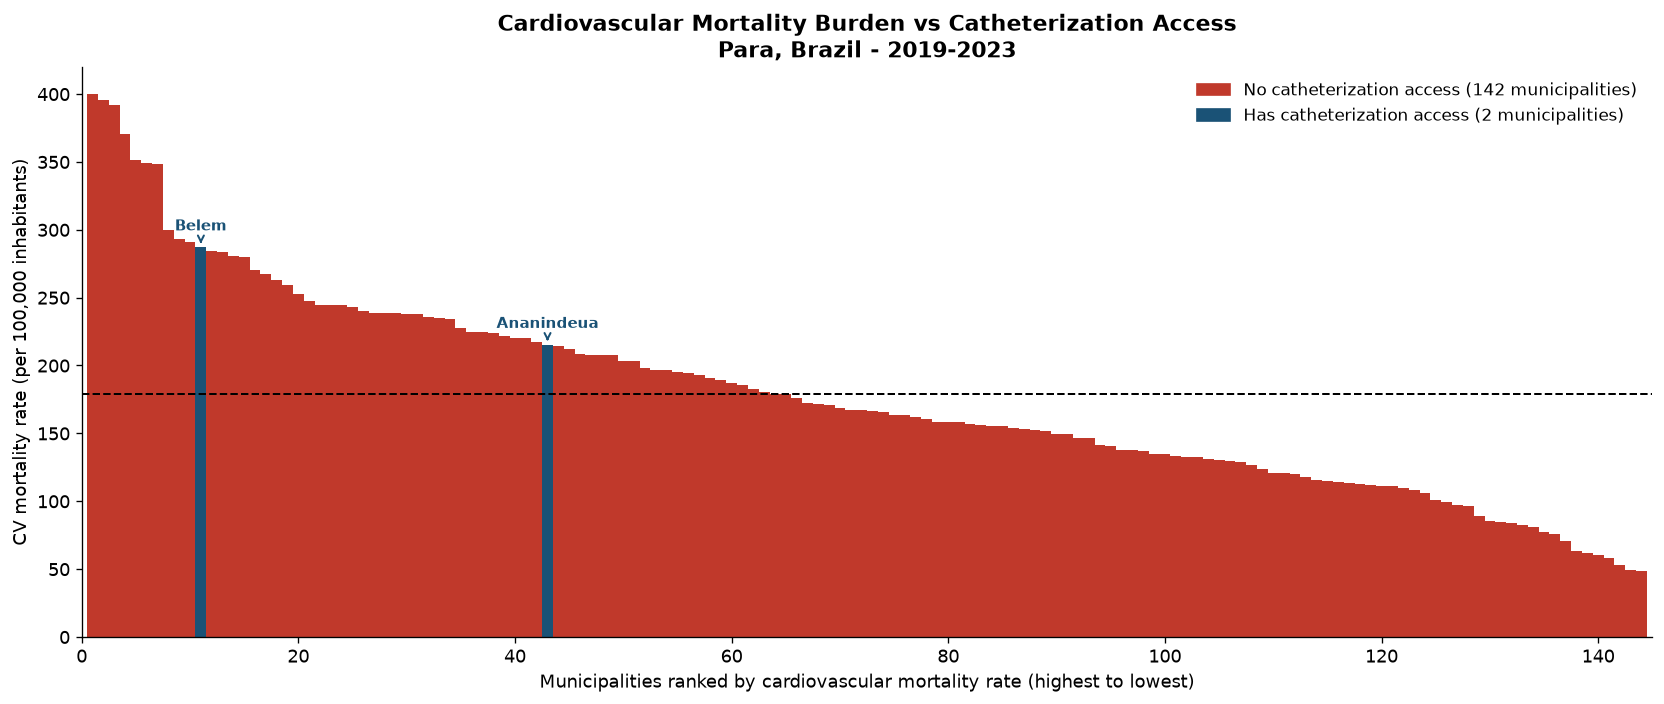

Figure saved: figures/06_access_gap.png
This is the central manuscript figure.


In [11]:
df_sorted = df.sort_values('taxa_mort_100k', ascending=False).reset_index(drop=True)
df_sorted['rank']     = range(1, len(df_sorted) + 1)
df_sorted['has_proc'] = df_sorted['aih_aprovadas'] > 0

fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = [ACCENT_RED if not h else '#1A5276' for h in df_sorted['has_proc']]
ax.bar(df_sorted['rank'], df_sorted['taxa_mort_100k'],
       color=bar_colors, edgecolor='none', width=1.0)

for _, row in df_sorted[df_sorted['has_proc']].iterrows():
    ax.annotate(row['nome_municipio'].title(),
                (row['rank'], row['taxa_mort_100k']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold', color='#1A5276',
                arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.2))

state_mean = df_sorted['taxa_mort_100k'].mean()
ax.axhline(state_mean, color='black', linestyle='--', linewidth=1.2,
           label=f'State mean: {state_mean:.1f} per 100k')

patch_no  = mpatches.Patch(color=ACCENT_RED, label='No catheterization access (142 municipalities)')
patch_yes = mpatches.Patch(color='#1A5276',  label='Has catheterization access (2 municipalities)')
ax.legend(handles=[patch_no, patch_yes], frameon=False, fontsize=10, loc='upper right')

ax.set_xlabel('Municipalities ranked by cardiovascular mortality rate (highest to lowest)')
ax.set_ylabel('CV mortality rate (per 100,000 inhabitants)')
ax.set_title('Cardiovascular Mortality Burden vs Catheterization Access\nPara, Brazil - 2019-2023',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, len(df_sorted) + 1)

plt.tight_layout()
plt.savefig('figures/06_access_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/06_access_gap.png')
print('This is the central manuscript figure.')

---
## Section 6 - EDA Summary for Manuscript

In [12]:
total_deaths  = int(df['mort_total'].sum())
total_proc_n  = int(df['aih_aprovadas'].sum())
total_pop     = int(df['populacao'].sum())
state_rate    = df['mort_total'].sum() / df['populacao'].sum() * 100_000
mean_rate     = df['taxa_mort_100k'].mean()
median_rate   = df['taxa_mort_100k'].median()
std_rate      = df['taxa_mort_100k'].std()
max_rate      = df['taxa_mort_100k'].max()
max_mun       = df.loc[df['taxa_mort_100k'].idxmax(), 'nome_municipio']
min_rate      = df['taxa_mort_100k'].min()
min_mun       = df.loc[df['taxa_mort_100k'].idxmin(), 'nome_municipio']
year_cols     = ['mort_2019','mort_2020','mort_2021','mort_2022','mort_2023']
yearly        = df[year_cols].sum()
years_list    = [2019,2020,2021,2022,2023]
peak_yr       = years_list[yearly.values.argmax()]
pct_without   = len(df[df['aih_aprovadas']==0]) / len(df) * 100
belem_share   = df['aih_aprovadas'].max() / total_proc_n * 100
corr_gdp      = df['taxa_mort_100k'].corr(df['pib_per_capita'])
ratio         = max_rate / min_rate

print('=' * 58)
print('EDA FINDINGS SUMMARY')
print('=' * 58)
print(f'Municipalities    : {len(df)}')
print(f'Population (2021) : {total_pop:,}')
print()
print('MORTALITY')
print(f'  Total CV deaths (2019-2023): {total_deaths:,}')
print(f'  State rate                 : {state_rate:.1f} per 100,000 inhabitants')
print(f'  Municipal mean (SD)        : {mean_rate:.1f} ({std_rate:.1f})')
print(f'  Municipal median           : {median_rate:.1f}')
print(f'  Highest rate               : {max_rate:.1f} - {max_mun.title()}')
print(f'  Lowest rate                : {min_rate:.1f} - {min_mun.title()}')
print(f'  Max/min ratio              : {ratio:.1f}x')
print(f'  Peak mortality year        : {peak_yr} ({int(yearly.max()):,} deaths)')
print()
print('ACCESS')
print(f'  Total catheterizations     : {total_proc_n:,}')
print(f'  Municipalities with access : 2 ({100-pct_without:.1f}%)')
print(f'  Municipalities without     : 142 ({pct_without:.1f}%)')
print(f'  Belem share of procedures  : {belem_share:.1f}%')
print()
print('ECONOMIC GRADIENT')
print(f'  Correlation GDP vs mortality: r = {corr_gdp:.3f}')
print(f'  Richest GDP per capita     : R${df["pib_per_capita"].max():,.0f}')
print(f'  Median GDP per capita      : R${df["pib_per_capita"].median():,.0f}')
print(f'  Poorest GDP per capita     : R${df["pib_per_capita"].min():,.0f}')
print('=' * 58)
print('Next: 03_clustering.ipynb')

EDA FINDINGS SUMMARY
Municipalities    : 144
Population (2021) : 8,777,124

MORTALITY
  Total CV deaths (2019-2023): 16,677
  State rate                 : 190.0 per 100,000 inhabitants
  Municipal mean (SD)        : 178.6 (74.8)
  Municipal median           : 166.9
  Highest rate               : 399.7 - Curionopolis
  Lowest rate                : 48.7 - Aveiro
  Max/min ratio              : 8.2x
  Peak mortality year        : 2023 (3,564 deaths)

ACCESS
  Total catheterizations     : 5,324
  Municipalities with access : 2 (1.4%)
  Municipalities without     : 142 (98.6%)
  Belem share of procedures  : 98.8%

ECONOMIC GRADIENT
  Correlation GDP vs mortality: r = 0.095
  Richest GDP per capita     : R$4,666,914
  Median GDP per capita      : R$124,172
  Poorest GDP per capita     : R$51,786
Next: 03_clustering.ipynb


---
## Completion Checklist

- [ ] `figures/02_procedure_concentration.png` saved
- [ ] `figures/03_mortality_distribution.png` saved
- [ ] `figures/04_temporal_trends.png` saved
- [ ] `figures/05_economic_gradient.png` saved
- [ ] `figures/06_access_gap.png` saved (central manuscript figure)
- [ ] EDA summary printed and reviewed

---
*Next: `03_clustering.ipynb` - K-Means Clustering & Map Visualization*